# **Tugas - 8 Clustering menggunakan Fuzzy C Means**

In [74]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing_fix.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,"Daftar Game PS4, PS5, Xbox, Nintendo Switch, d...","Jakarta - Meskipun 2024 segera berakhir, tapi ...","Rabu, 04 Des 2024 22:06 WIB",Games,Jakarta Meskipun segera berakhir tapi sedere...,jakarta meskipun segera berakhir tapi sedere...,"['jakarta', 'meskipun', 'segera', 'berakhir', ...",jakarta sederet studio game berhenti merilis k...
1,"Asyik, Lionel Messi Bakal Cosplay Jadi Captain...",Jakarta - Konami resmi mengumumkan kerja sama ...,"Rabu, 04 Des 2024 16:38 WIB",Games,Jakarta Konami resmi mengumumkan kerja sama t...,jakarta konami resmi mengumumkan kerja sama t...,"['jakarta', 'konami', 'resmi', 'mengumumkan', ...",jakarta konami resmi mengumumkan kerja terbaru...
2,"Rayakan Ultah ke-30, PlayStation Diskon Game P...",Jakarta - Dalam rangka merayakan hari ulang ta...,"Rabu, 04 Des 2024 14:34 WIB",Games,Jakarta Dalam rangka merayakan hari ulang tah...,jakarta dalam rangka merayakan hari ulang tah...,"['jakarta', 'dalam', 'rangka', 'merayakan', 'h...",jakarta rangka merayakan ulang sony playstatio...
3,Jadwal M6 Mobile Legends Hari Ini: Team Liquid...,Jakarta - Tiga pertandingan akan berlangsung h...,"Rabu, 04 Des 2024 10:45 WIB",Games,Jakarta Tiga pertandingan akan berlangsung ha...,jakarta tiga pertandingan akan berlangsung ha...,"['jakarta', 'tiga', 'pertandingan', 'akan', 'b...",jakarta pertandingan lanjutan babak swiss stag...
4,Animasi Ikonik PSX Diboyong ke PS5,Jakarta - Sony merilis pembaruan menarik untuk...,"Rabu, 04 Des 2024 06:15 WIB",Games,Jakarta Sony merilis pembaruan menarik untuk ...,jakarta sony merilis pembaruan menarik untuk ...,"['jakarta', 'sony', 'merilis', 'pembaruan', 'm...",jakarta sony merilis pembaruan menarik playsta...


In [77]:
texts = df['Hasil stopword']

In [78]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [79]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 4204)

In [80]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.000001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9612002947926014, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=3: Silhouette=0.9451248208379439, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=4: Silhouette=0.8366947773915437, ARI=0.02269374787246114, NMI=0.1212746751286823
Iterasi dengan n_components=5: Silhouette=0.7419971550075583, ARI=0.06331965466434494, NMI=0.18500252551479732
Iterasi dengan n_components=6: Silhouette=0.709924074764957, ARI=0.08528784648187633, NMI=0.21020079396118754
Iterasi dengan n_components=7: Silhouette=0.6691577968592649, ARI=0.09749914688246478, NMI=0.22286943775271859
Iterasi dengan n_components=8: Silhouette=0.524041496046515, ARI=0.20591790142799588, NMI=0.3153209246502265
Iterasi dengan n_components=9: Silhouette=0.32285062076879384, ARI=0.513874614594039, NMI=0.5301510681963296
Iterasi dengan n_components=10: Silhouette=0.43912582080250007, ARI=0.3077261613691932, NMI=0.3400257563290699
Iterasi dengan n_components=11: Silho

In [81]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.9612002947926014
Best ARI is achieved by n_components=27 with score: 0.8824127248460211
Best NMI is achieved by n_components=27 with score: 0.8079616479391557


In [82]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.9612002947926014

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.9612002947926014, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=3: Silhouette Score={'silhouette': 0.9451248208379439, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=4: Silhouette Score={'silhouette': 0.8366947773915437, 'ari': 0.02269374787246114, 'nmi': 0.1212746751286823}
n_components=5: Silhouette Score={'silhouette': 0.7419971550075583, 'ari': 0.06331965466434494, 'nmi': 0.18500252551479732}
n_components=6: Silhouette Score={'silhouette': 0.709924074764957, 'ari': 0.08528784648187633, 'nmi': 0.21020079396118754}
n_components=7: Silhouette Score={'silhouette': 0.6691577968592649, 'ari': 0.09749914688246478, 'nmi': 0.22286943775271859}
n_components=8: Silhouette Score={'silhouette': 0.524041496046515, 'ari': 0.20591790142799588, 'nmi': 0.3153209246502265}
n_components=10: Silhouette Score={'silhouette': 0.43912582

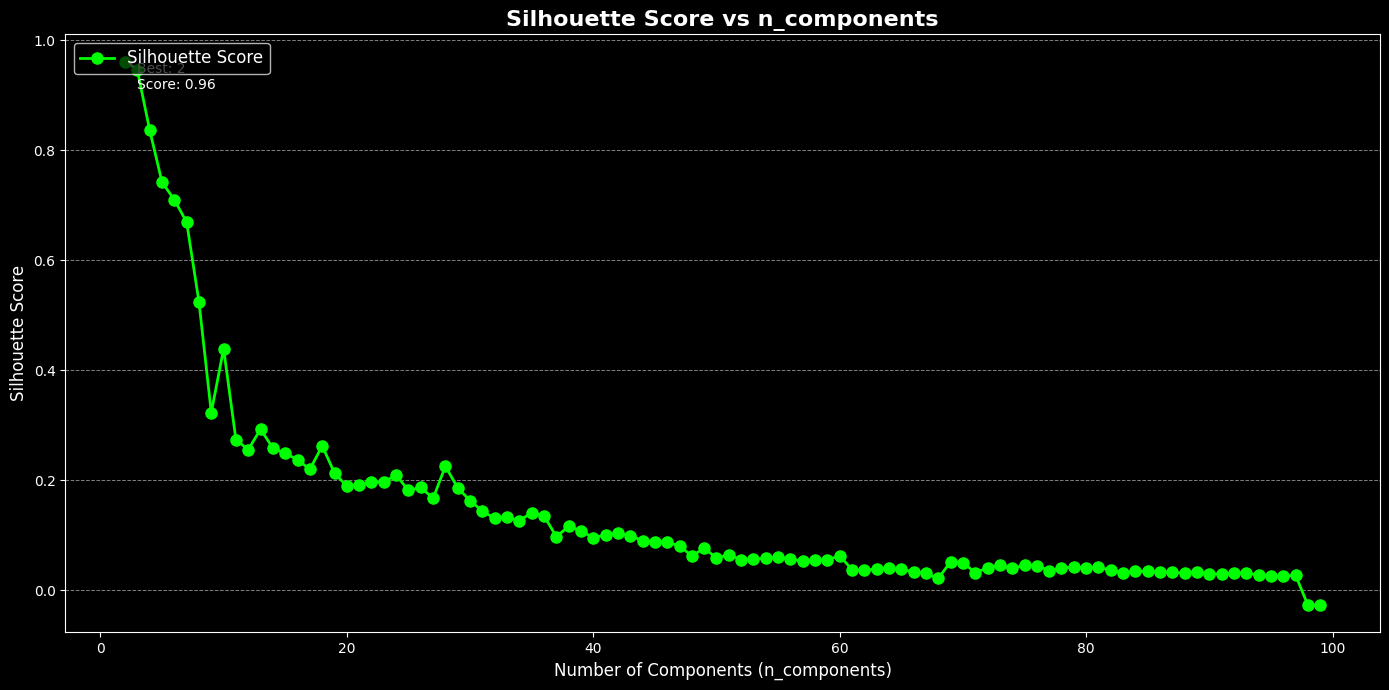

In [83]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

## Clustering

Silhouette Score: 0.1669
Jumlah data pada setiap cluster:
Cluster
1    51
0    49
Name: count, dtype: int64


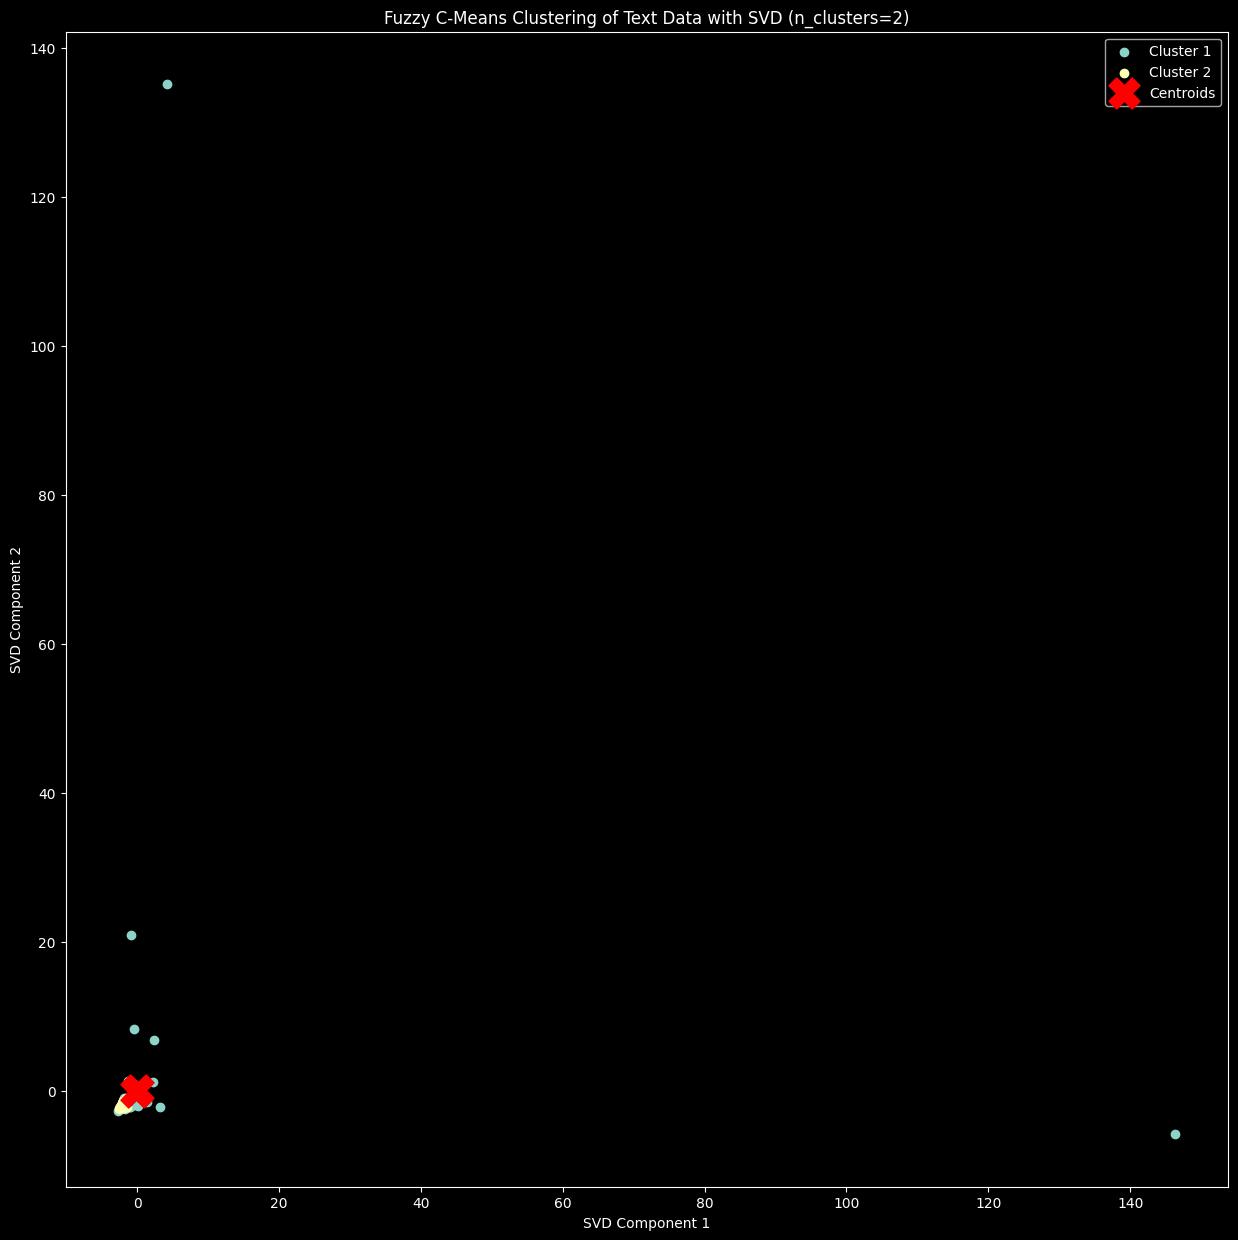

In [94]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing_fix.csv')
data = df['Hasil stopword']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=27 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)



# Fuzzy C-Means Clustering
n_clusters = 2  # Ganti sesuai kebutuhan
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.00001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(15, 15))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=500, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [95]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

    id    kategori  Cluster
0    0       Games        0
1    1       Games        0
2    2       Games        0
3    3       Games        0
4    4       Games        1
..  ..         ...      ...
95  95  Sepak Bola        1
96  96  Sepak Bola        1
97  97  Sepak Bola        1
98  98  Sepak Bola        1
99  99  Sepak Bola        1

[100 rows x 3 columns]


In [96]:
# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

Anggota Cluster 0: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 60]
Anggota Cluster 1: [4, 21, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


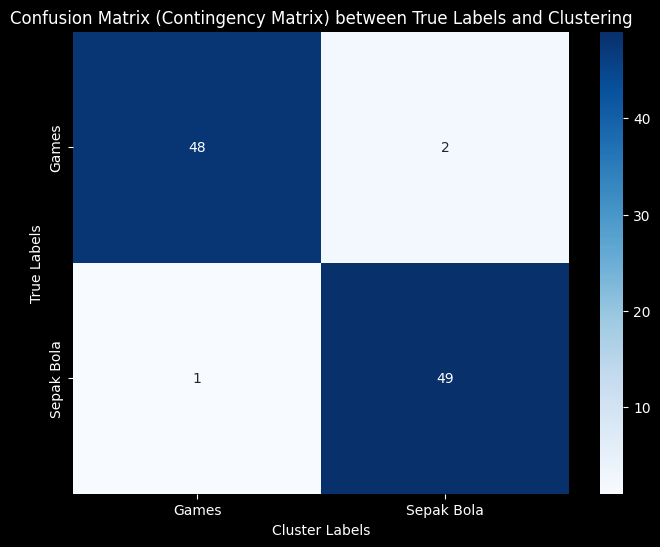

Confusion Matrix (Contingency Matrix):
[[48  2]
 [ 1 49]]


In [97]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [98]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.1669


In [99]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing_fix.csv')
data = df['Hasil stopword'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=2.0,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.00001,      # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Membuat pipeline dengan FCM dan parameter yang diberikan
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # TF-IDF untuk teks
    ('scaler', StandardScaler(with_mean=False)),  # Normalisasi data
    ('svd', TruncatedSVD(n_components=17)),  # Reduksi Dimensi
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))  # Menggunakan FCM melalui FunctionTransformer
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [100]:
# Membaca data
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing_fix.csv')
data = df['Hasil stopword'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,
        m=2.0,
        max_iter=1000,
        epsilon=0.00001,
        random_state=42
    )
    fcm.fit(X)
    return fcm

# Pipeline tanpa FCM
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('scaler', StandardScaler(with_mean=False)),
    ('svd', TruncatedSVD(n_components=23))
])

# Fit pipeline pada data
transformed_data = pipeline.fit_transform(data)

# Jalankan FCM pada data yang sudah diproses
fcm_result = fit_fcm(transformed_data)

# Simpan pipeline dan hasil FCM
joblib.dump((pipeline, fcm_result), 'fcm_pipeline.pkl')

['fcm_pipeline.pkl']

In [101]:
from fcmeans import FCM
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import joblib

# Fungsi untuk menerapkan FCM
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,
        m=2.0,
        max_iter=1000,
        epsilon=0.00001,
        random_state=42
    )
    fcm.fit(X)
    return fcm

# Pipeline tanpa FCM
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # TF-IDF untuk teks
    ('scaler', StandardScaler(with_mean=False)),  # Normalisasi data
    ('svd', TruncatedSVD(n_components=11))  # Reduksi Dimensi
])

# Fit pipeline pada data
transformed_data = pipeline.fit_transform(data)  # Pastikan 'data' sudah diproses sebelumnya

# Jalankan FCM pada data yang sudah diproses
fcm_result = fit_fcm(transformed_data)

# Simpan pipeline dan hasil FCM dalam satu file (tuple)
joblib.dump((pipeline, fcm_result), 'fcm_pipeline_fix.pkl')

['fcm_pipeline_fix.pkl']

In [104]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import numpy as np
import pandas as pd

# 1. Memuat pipeline yang sudah dilatih sebelumnya
pipeline = joblib.load('svd_tfidf_scaler_fcm_pipeline.pkl')

# 2. Melakukan FCM pada data pelatihan (sudah dilabeli Games dan Sepakbola)
# Misalnya, kita memiliki data pelatihan yang dilabeli sebagai berikut:
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing_fix.csv')  # Ganti dengan path data pelatihan Anda
data_pelatihan = df['Hasil stopword']  # Kolom yang berisi teks

# Transformasi data pelatihan menggunakan pipeline
X_train_transformed = pipeline[:-1].transform(data_pelatihan)  # Tanpa FCM, hanya TF-IDF, Scaling, dan SVD
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# 3. Melakukan clustering FCM pada data pelatihan
fcm_model = FCM(n_clusters=2, m=2.0, max_iter=1000, epsilon=0.00001, random_state=42)
fcm_model.fit(X_train_transformed)

# 4. Menyelaraskan cluster dengan label yang diketahui (Games = 0, Sepakbola = 1)
# Misalnya, jika label pada data pelatihan adalah:
labels_train = df['kategori']  # Kolom label, yang bisa berisi 0 (Games) dan 1 (Sepakbola)

# Menyelaraskan cluster dengan label
cluster_labels = fcm_model.predict(X_train_transformed)
# Misalkan cluster 0 harus menjadi Games dan cluster 1 harus menjadi Sepakbola
cluster_to_label = {0: 'Games', 1: 'Sepak bola'}

# Menyelaraskan prediksi cluster dengan label
predicted_labels = [cluster_to_label[cluster] for cluster in cluster_labels]

# 5. Memuat data baru untuk prediksi
teks_baru = """Liputan6.com, Jakarta - Para gamer pencinta jenis game MMORPG kini bisa mencoba lebih dahulu game terbaru dari Gravity Game Link, Ragnarok Classic.
Pasalnya, pengembang asal Korea ini belum lama ini resmi mengumumkan fase closed beta (CBT) dari game PC ini.
Sekadar informasi, Ragnarok Classic merupakan game yang dirancang untuk menghadirkan kembali pengalaman bermain otentik dan membangkitkan nostalgia bagi penggemar Ragnarok.
"""

# Transformasi data baru menggunakan pipeline
X_new_transformed = pipeline[:-1].transform([teks_baru])
if hasattr(X_new_transformed, 'toarray'):
    X_new_transformed = X_new_transformed.toarray()

# 6. Prediksi cluster untuk data baru
cluster_new = fcm_model.predict(X_new_transformed)

# Menyelaraskan prediksi cluster dengan label
predicted_label_new = cluster_to_label[cluster_new[0]]

# 7. Menampilkan hasil
print(f"Teks baru ini diprediksi ke dalam cluster: {predicted_label_new}")


Teks baru ini diprediksi ke dalam cluster: Games


In [103]:
'''Data test : Liputan6.com, Jakarta - Para gamer pencinta jenis game MMORPG kini bisa mencoba lebih dahulu game terbaru dari Gravity Game Link, Ragnarok Classic.
Pasalnya, pengembang asal Korea ini belum lama ini resmi mengumumkan fase closed beta (CBT) dari game PC ini.
Sekadar informasi, Ragnarok Classic merupakan game yang dirancang untuk menghadirkan kembali pengalaman bermain otentik dan membangkitkan nostalgia bagi penggemar Ragnarok.'''

'Data test : Liputan6.com, Jakarta - Para gamer pencinta jenis game MMORPG kini bisa mencoba lebih dahulu game terbaru dari Gravity Game Link, Ragnarok Classic.\nPasalnya, pengembang asal Korea ini belum lama ini resmi mengumumkan fase closed beta (CBT) dari game PC ini.\nSekadar informasi, Ragnarok Classic merupakan game yang dirancang untuk menghadirkan kembali pengalaman bermain otentik dan membangkitkan nostalgia bagi penggemar Ragnarok.'